In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

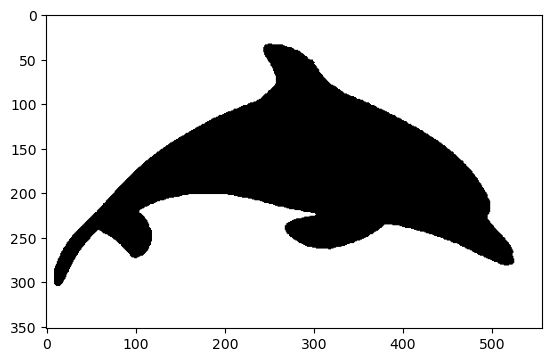

In [11]:
I = cv2.imread('imágenes/Delfin.png',cv2.IMREAD_GRAYSCALE)

umbral, Iu = cv2.threshold(I, 0,255, cv2.THRESH_OTSU | cv2.THRESH_BINARY)
# Display the image
fg1, ax1 = plt.subplots()
_ =ax1.imshow(Iu, cmap='Greys')

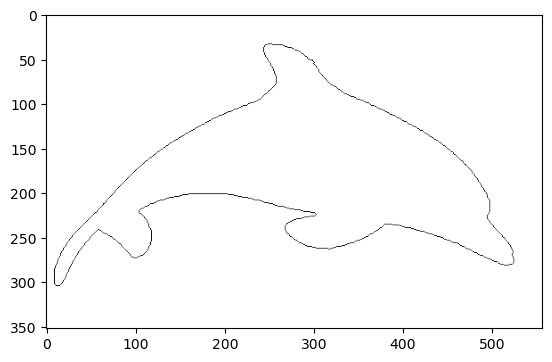

In [14]:
# Invocamos la funcion findContours.
# Nótese que ignoramos por el momento la información jerárquica

contornos, _ = cv2.findContours(Iu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# El numero de contornos encontrados.

nC = len(contornos)

# Dibujamos los contornos.

O=np.zeros(Iu.shape,dtype=np.uint8)

for i in range(nC):
    for contCoor in contornos[i]:
        c,r = contCoor[0,:]
        O[r,c] = 255
        
fg2, ax2 = plt.subplots()
ax2.imshow(O, cmap='Greys')
plt.show()

El centroide de nuestra función es: (294.25902459039855, 176.09935080838827)


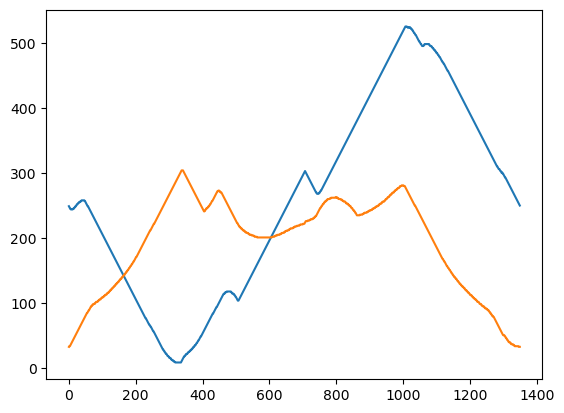

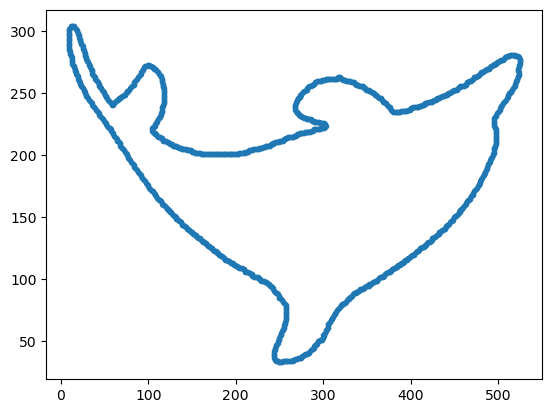

In [24]:
mm = cv2.moments(contornos[0])
n = len(contornos[0])
xm = mm['m10'] / mm['m00']
ym = mm['m01'] / mm['m00']
print ("El centroide de nuestra función es:", (xm, ym))

fx = np.zeros(n)
fy = np.zeros(n)

i = 0
for contCoor in contornos[0]:
    c, r = contCoor[0,:]
    fx[i] = c
    fy[i] = r
    i+=1
    
t = np.linspace(0, n, n)
fg3, ax3 = plt.subplots()
ax3.plot(t, fx, t, fy)
plt.show()

C = np.vstack([fx, fy])
C.shape

fg4, ax4 = plt.subplots()
ax4.plot(fx, fy, '.')
plt.show()
